# Customer and Fare Analysis in Taxi Services

*The Taxi Dataset is analyzed to explore trip characteristics, fare patterns, payment methods, and customer behavior using visualization and statistical techniques. The study provides meaningful insights through data preprocessing and exploratory data analysis.*

IMPORTING LIBRARIES

In [39]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
df=sns.load_dataset('taxis')

Top 5 Rows Of Dataset

In [63]:
df.head()

,passengers,distance,fare,tip,total,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,1.0,1.600,7.0,2.15,12.95,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,1.0,0.790,5.0,0.00,9.30,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,1.0,1.370,7.5,2.36,14.16,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,1.0,6.555,27.0,6.15,34.55,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,3.0,2.160,9.0,1.10,13.40,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [64]:
df.describe()

,passengers,distance,fare,tip,total
count,6433.000000,6433.000000,6433.000000,6433.000000,6433.000000
mean,1.406653,2.402856,11.730843,1.833852,16.724455
std,0.813367,1.948847,7.156878,1.900430,8.157420
min,0.000000,0.000000,1.000000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.700000,14.160000
75%,2.000000,3.210000,15.000000,2.800000,20.300000
max,3.500000,6.555000,27.750000,7.000000,34.550000


In [65]:
df.shape

(6433, 10)

In [66]:
df.duplicated().sum()

np.int64(47)

In [67]:
df=df.drop_duplicates()

In [68]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

In [44]:
df=df.drop(["pickup","dropoff","color","tolls"],axis=1)

In [45]:
df

,passengers,distance,fare,tip,total,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,1,1.60,7.0,2.15,12.95,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,1,0.79,5.0,0.00,9.30,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,1,1.37,7.5,2.36,14.16,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,1,7.70,27.0,6.15,36.95,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,3,2.16,9.0,1.10,13.40,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...
6428,1,0.75,4.5,1.06,6.36,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,1,18.74,58.0,0.00,58.80,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,1,4.14,16.0,0.00,17.30,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,1,1.12,6.0,0.00,6.80,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


# DATA PREPROCESSING

## Missing Value Handling:

In [46]:
df.isnull().sum()

passengers          0
distance            0
fare                0
tip                 0
total               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [47]:
for i in ["payment","pickup_zone","dropoff_zone","pickup_borough","dropoff_borough"]:
    df[i]=df[i].fillna(df[i].mode()[0])

In [48]:
df.isnull().sum()

passengers         0
distance           0
fare               0
tip                0
total              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

## Outlier Handling:

<Axes: >

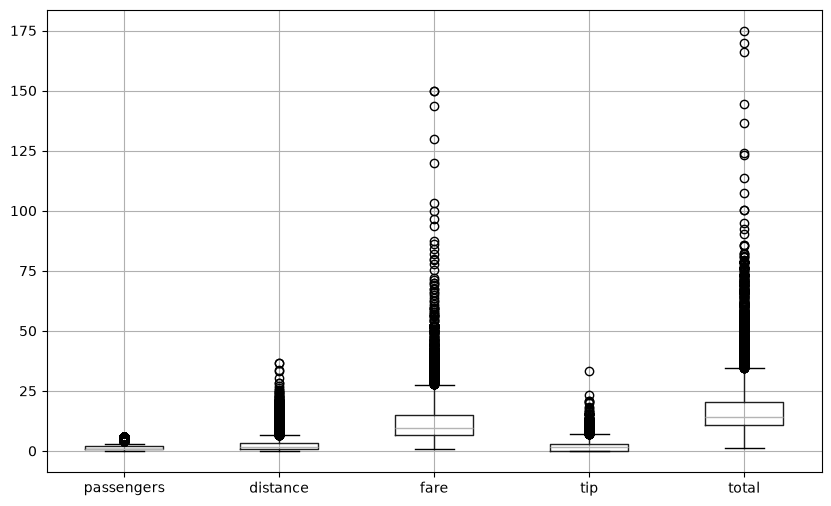

In [49]:
plt.figure(figsize=(10,6))
df.boxplot()

In [50]:
for i in ['passengers', 'distance', 'fare', 'tip','total']:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)
    

<Axes: >

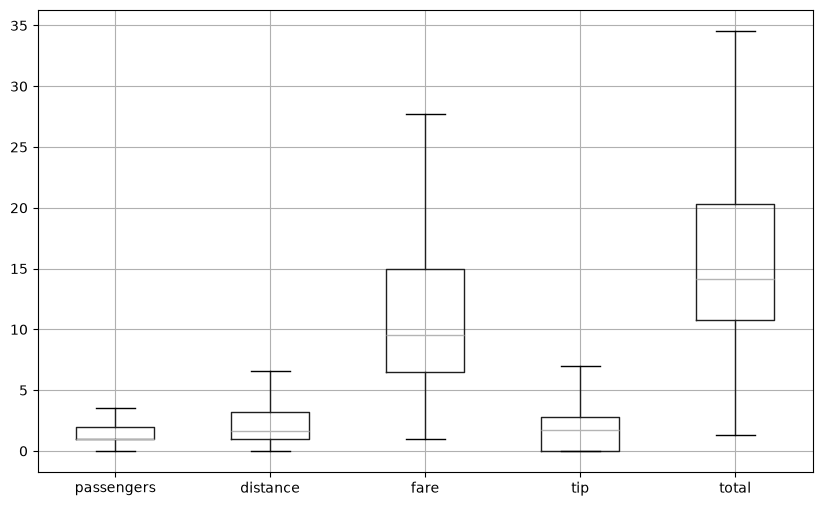

In [51]:
plt.figure(figsize=(10,6))
df.boxplot()

In [52]:
dist_total=df.groupby("payment")["total"].mean()
dist_total

payment
cash           13.678046
credit card    17.919022
Name: total, dtype: float64

Credit card payments have a higher average total fare (17.92) than cash payments (13.70), indicating greater spending by credit card users.

In [53]:
overall=df.groupby(["dropoff_borough","payment"])["total"].mean()
overall

dropoff_borough  payment    
Bronx            cash           17.552885
                 credit card    23.120471
Brooklyn         cash           15.929150
                 credit card    22.682586
Manhattan        cash           13.167095
                 credit card    16.886164
Queens           cash           14.363565
                 credit card    23.906795
Staten Island    credit card    34.550000
Name: total, dtype: float64

Credit card payments have higher average fares than cash payments in all boroughs. Staten Island shows the highest average fare, while Manhattan has the lowest. This suggests that higher-value taxi trips are more commonly paid for using credit cards.

## Univariate Analysis

<Figure size 1500x900 with 0 Axes>

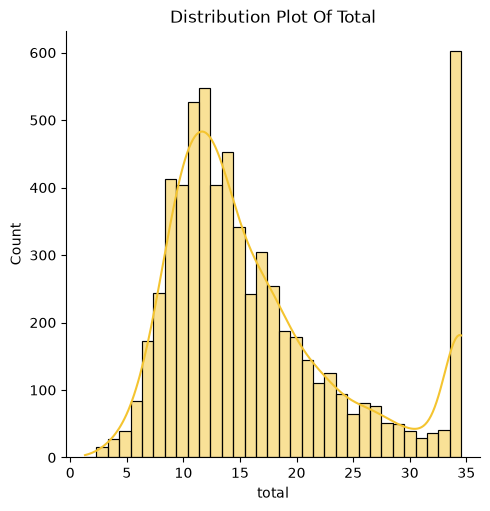

In [ ]:
plt.figure(figsize=(10,6))
sns.displot(df["total"],kde=True,color="#F4C430")
plt.title("Distribution Plot Of Total")
plt.show()

Most taxi trips have moderate total fares, while high-fare trips are less frequent. The distribution is slightly right-skewed, indicating a few trips with unusually high total amounts.

Text(0.5, 1.0, 'Pickup Locations')

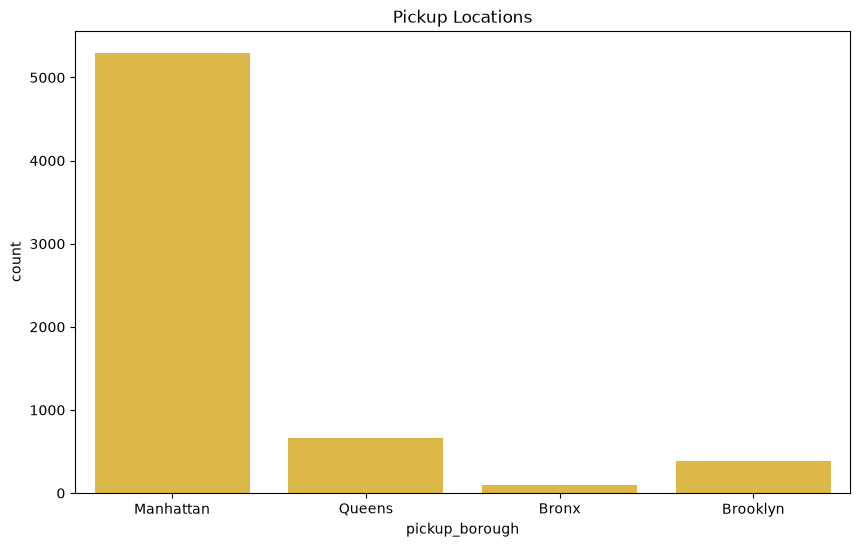

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(x="pickup_borough",data=df,color="#F4C430")
plt.title("Pickup Locations")

Most taxi pickups occur in Manhattan, indicating it is the busiest pickup borough. Queens has a significantly lower number of pickups, while Brooklyn and Bronx contribute only a small share of total pickups.

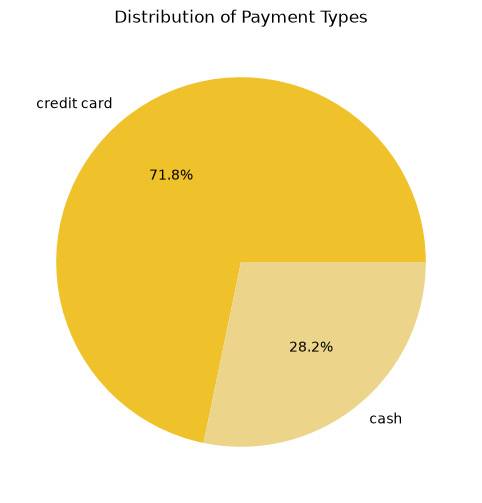

In [75]:
payment_counts = df['payment'].value_counts()
plt.figure(figsize=(10,6))
colors={"#EDD48B","#EFC22B"}
plt.pie(payment_counts,labels=payment_counts.index,autopct='%1.1f%%',colors=colors)
plt.title("Distribution of Payment Types")
plt.show()

The pie chart shows the distribution of payment methods used by passengers. Credit card payments account for the largest share of transactions, while cash payments represent a smaller proportion, indicating a preference for digital payments among taxi users.

## Bivariate Analysis

Text(0.5, 1.0, 'Scatterplot of Distance and Total')

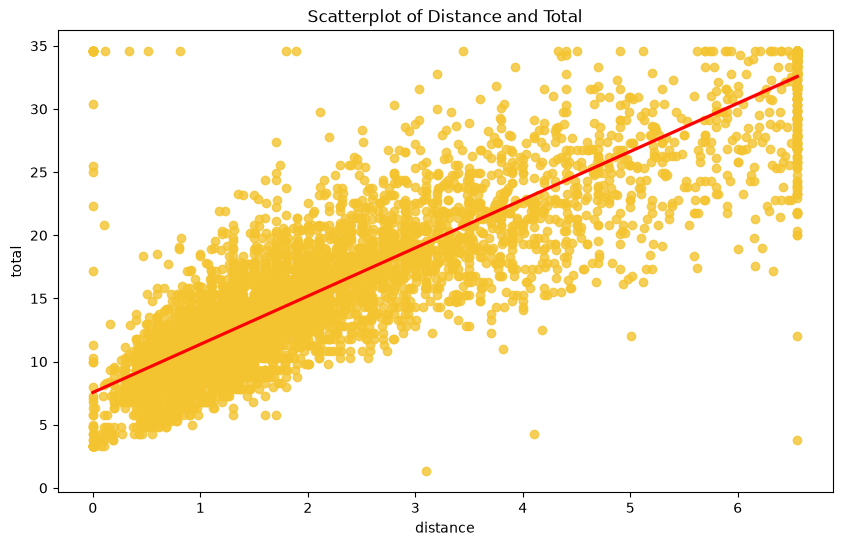

In [56]:
plt.figure(figsize=(10,6))
sns.regplot(x="distance",y="total",data=df,scatter_kws={"color":"#F4C430"},line_kws={"color":"Red"})
plt.title("Scatterplot of Distance and Total")

There is a positive relationship between distance and total fare. As trip distance increases, the total fare generally increases. The upward regression line confirms a moderate positive correlation between the two variables.

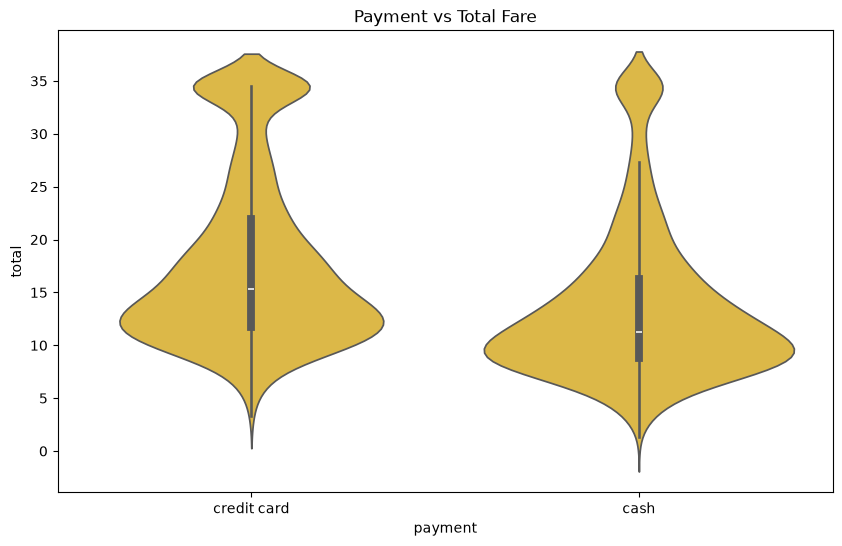

In [57]:
plt.figure(figsize=(10,6))
sns.violinplot(x="payment",y="total",data=df,color="#F4C430")
plt.title("Payment vs Total Fare")
plt.show()

Passengers paying by credit card tend to have higher total fares, while cash payments are generally associated with lower-cost trips.

## Multivariate Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

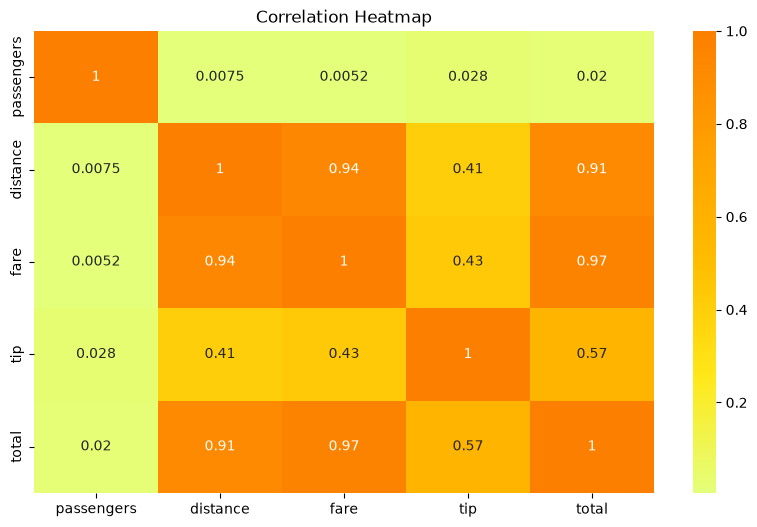

In [59]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Wistia")
plt.title("Correlation Heatmap")

Distance vs Fare = 0.94 → Very strong positive relationship. Longer trips generally result in higher fares.

Distance vs Total = 0.91 → Strong positive relationship. Total fare increases as trip distance increases.

Fare vs Total = 0.97 → Strongest correlation visible. Fare is the major contributor to the total amount.

Tip vs Total = 0.57 → Moderate positive relationship. Higher total fares tend to receive higher tips.

Passengers vs Other Variables ≈ 0 → Almost no relationship. Passenger count has little impact on fare, tip, or total amount.